<a href="https://colab.research.google.com/github/Ming-gyu/bio-career-toolkit/blob/main/QC_%EA%B4%80%EB%A6%AC%EB%8F%84_%EC%8B%A4%EC%8A%B5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# QC 데이터로 관리도 그려보기

이 노트북은 QC(품질관리) 실험실에서 매일 마주치는 상황 — **완제의약품 함량시험 결과를 관리도(Control Chart)로 감시하는 것** — 을 파이썬으로 직접 해보는 실습입니다.

설치는 필요 없습니다. 위쪽 메뉴에서 **런타임 → 모두 실행**을 누르면 순서대로 실행됩니다. 셀을 하나씩 실행하며 코드를 눈으로 따라가 보는 것을 추천합니다(각 셀을 클릭하고 `Shift+Enter`).

**시나리오**: 어떤 정제(tablet)의 표시함량 기준은 95.0~105.0%(목표 100%)입니다. 30개 배치(batch)에서 매일 하나씩 함량시험을 진행했다고 가정하고, 그 데이터를 가상으로 만들어 분석합니다.

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 재현 가능하도록 시드 고정
np.random.seed(42)

n_batches = 30
target = 100.0          # 목표 함량(%)
process_sd = 1.8         # 공정이 실제로 가진 변동(표준편차)

# 정상적인 공정에서 나온 함량시험 결과를 가상으로 생성
assay = np.random.normal(loc=target, scale=process_sd, size=n_batches)

# 26번째 배치부터 원료 로트가 바뀌며 살짝 낮은 쪽으로 치우쳤다고 가정(현실적인 '변화' 시나리오)
assay[25:] -= 3.2

df = pd.DataFrame({
    "batch_no": [f"B{i+1:03d}" for i in range(n_batches)],
    "assay_pct": assay.round(2)
})
df.head(10)

,batch_no,assay_pct
0,B001,100.89
1,B002,99.75
2,B003,101.17
3,B004,102.74
4,B005,99.58
5,B006,99.58
6,B007,102.84
7,B008,101.38
8,B009,99.15
9,B010,100.98


## 함량시험 결과 요약 통계

QC에서 가장 먼저 보는 숫자 세 가지: **평균(mean)**, **표준편차(SD)**, 그리고 상대표준편차 **%RSD**(변동이 평균 대비 얼마나 큰지)입니다.

In [8]:
mean_val = df["assay_pct"].mean()
sd_val = df["assay_pct"].std(ddof=1)
rsd_pct = (sd_val / mean_val) * 100

print(f"평균(Mean): {mean_val:.2f}%")
print(f"표준편차(SD): {sd_val:.2f}")
print(f"상대표준편차(%RSD): {rsd_pct:.2f}%")
print()
print("참고: 일반적으로 함량균일성 시험 등에서 %RSD가 낮을수록(보통 2% 미만) 공정·분석이 안정적이라고 봅니다.")
print("(정확한 판정 기준은 시험법·의약품마다 다르므로 실제 업무에서는 해당 SOP·약전 기준을 따라야 합니다.)")

평균(Mean): 99.13%
표준편차(SD): 2.08
상대표준편차(%RSD): 2.10%

참고: 일반적으로 함량균일성 시험 등에서 %RSD가 낮을수록(보통 2% 미만) 공정·분석이 안정적이라고 봅니다.
(정확한 판정 기준은 시험법·의약품마다 다르므로 실제 업무에서는 해당 SOP·약전 기준을 따라야 합니다.)


## 관리도(Shewhart X-bar Chart) 그리기

관리도는 "이 공정이 평소와 같은 상태로 운영되고 있는가"를 한눈에 보여주는 그래프입니다.

- **중심선(CL)**: 공정의 평균
- **관리상한/하한(UCL/LCL)**: 평균 ± 3×SD — 이 선을 벗어나면 "공정에 이상이 생겼다"는 강한 신호
- **경고선**: 평균 ± 2×SD — 참고용 경고 구간
- **규격선(Spec limit)**: 95.0% / 105.0% — 실제 출하 가능 여부를 가르는 기준(관리도의 통계적 한계와는 별개입니다)

/tmp/ipykernel_487/246583110.py:28: UserWarning: Glyph 48176 (\N{HANGUL SYLLABLE BAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_487/246583110.py:28: UserWarning: Glyph 52824 (\N{HANGUL SYLLABLE CI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_487/246583110.py:28: UserWarning: Glyph 48264 (\N{HANGUL SYLLABLE BEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_487/246583110.py:28: UserWarning: Glyph 54840 (\N{HANGUL SYLLABLE HO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_487/246583110.py:28: UserWarning: Glyph 54632 (\N{HANGUL SYLLABLE HAM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_487/246583110.py:28: UserWarning: Glyph 47049 (\N{HANGUL SYLLABLE RYANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_487/246583110.py:28: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tm

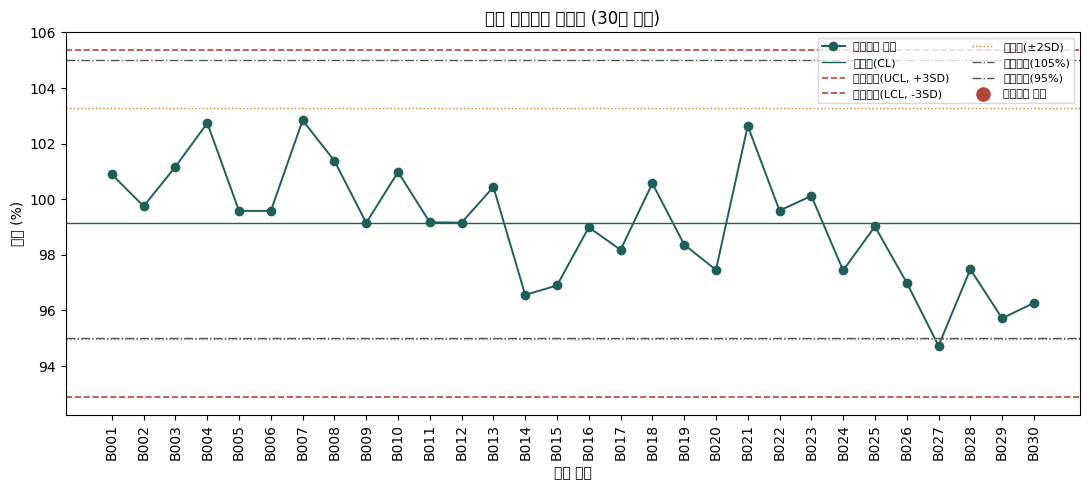

관리한계를 벗어난 배치 수: 0개


In [9]:
ucl = mean_val + 3 * sd_val
lcl = mean_val - 3 * sd_val
warn_hi = mean_val + 2 * sd_val
warn_lo = mean_val - 2 * sd_val
spec_hi, spec_lo = 105.0, 95.0

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(df["batch_no"], df["assay_pct"], marker="o", linewidth=1.4, color="#1f5f5b", label="함량시험 결과")

ax.axhline(mean_val, color="#1f5f5b", linestyle="-", linewidth=1, label="중심선(CL)")
ax.axhline(ucl, color="#b0473a", linestyle="--", linewidth=1.2, label="관리상한(UCL, +3SD)")
ax.axhline(lcl, color="#b0473a", linestyle="--", linewidth=1.2, label="관리하한(LCL, -3SD)")
ax.axhline(warn_hi, color="#d97b29", linestyle=":", linewidth=1, label="경고선(±2SD)")
ax.axhline(warn_lo, color="#d97b29", linestyle=":", linewidth=1)
ax.axhline(spec_hi, color="#555", linestyle="-.", linewidth=1, label="규격상한(105%)")
ax.axhline(spec_lo, color="#555", linestyle="-.", linewidth=1, label="규격하한(95%)")

# 관리한계를 벗어난 점을 빨간 점으로 강조
out_of_control = (df["assay_pct"] > ucl) | (df["assay_pct"] < lcl)
ax.scatter(df.loc[out_of_control, "batch_no"], df.loc[out_of_control, "assay_pct"],
           color="#b0473a", s=90, zorder=5, label="관리한계 이탈")

ax.set_title("정제 함량시험 관리도 (30개 배치)")
ax.set_xlabel("배치 번호")
ax.set_ylabel("함량 (%)")
ax.tick_params(axis="x", rotation=90)
ax.legend(loc="upper right", fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

print(f"관리한계를 벗어난 배치 수: {out_of_control.sum()}개")
if out_of_control.sum() > 0:
    print("→ 벗어난 배치:", df.loc[out_of_control, "batch_no"].tolist())

## 결과 해석

그래프를 실행해 보면 뒤쪽 배치들(원료 로트가 바뀐 이후)이 평균보다 낮은 쪽으로 몰려있는 게 보일 겁니다. 실제 QC 현장이라면 이런 패턴을 아래처럼 해석합니다.

- 한 점이 관리한계(UCL/LCL)를 벗어남 → 그 배치는 즉시 **일탈(Deviation)** 조사 대상
- 관리한계 안에 있어도 여러 점이 한쪽으로 연속해서 치우침(Run) → 공정에 **체계적인 변화**(원료 로트 교체, 설비 노후화 등)가 생겼다는 신호로 보고 원인조사(Root Cause Analysis)를 시작
- 규격선(95~105%)은 넘지 않았더라도 관리한계를 벗어났다면, "아직 불량은 아니지만 공정이 통제를 벗어나고 있다"는 조기 경보로 취급합니다

이 노트북의 코드에서 `assay[25:] -= 3.2` 부분의 숫자를 바꿔보면서 "변화가 얼마나 커야 관리도가 잡아내는지" 직접 실험해 보세요.

## 다음 단계

- 이 노트북 파일(.ipynb)을 그대로 GitHub 저장소에 올리면, 코드와 그래프가 함께 저장되어 **"데이터 기반으로 QC를 이해하고 있다"**는 근거 자료가 됩니다.
- 실제 업무에서는 셀인 교육이나 KPBMA 자료에서 다룬 **관리도·통계적공정관리(SPC)** 개념과 연결해서, 자소서나 면접에서 "AI 도구로 QC 데이터 분석을 직접 연습해 봤다"는 구체적 사례로 쓸 수 있습니다.
- 궁금하면 시도해볼 것: `process_sd` 값을 키워보며 %RSD가 어떻게 변하는지, 배치 수(`n_batches`)를 늘려보며 관리도가 더 안정적으로 보이는지 관찰해 보세요.